# Introduction to Torx factors and directed factor graphs


<div class="note"><span class="note-t">In brief</span>
<p>We define four tutorial factors, sample each one on its own, then compose them with Torx's factor bases, sampler, directed graph, and composite factors, so a single sampling interface carries from one probabilistic bit up to a whole graph. Because Torx <code>TiledFactor</code> and <code>ChainFactor</code> are meant to be bookkeeping around a factor and nothing more, we rerun them with the same random keys as manual JAX equivalents and require the draws to agree exactly.</p>
</div>


In this tutorial we start from the smallest object Torx can sample, a single **probabilistic bit** (pbit), and build upward from there. We give that pbit a factor of its own, wire two factors into a Torx directed factor graph, and then connect the resulting software hierarchy to the parametrised stochastic circuit (PSC) view used elsewhere in the gallery.

A **factor** is one conditional distribution packaged as an object. It reads named inputs, reads parameters that live outside the object and arrive with each call, and returns one stochastic output. Keeping the parameters outside is what makes a factor reusable, because the object itself carries no numbers to get stale. Four factors carry the teaching here: `CoinFactor`, `ConditionalBit`, `TinyCategorical`, and `FlipFactor` are defined in this notebook and are not Torx library primitives, while the base classes, sampler, graph, and composites that combine them all come from Torx.

A **directed factor graph** is a set of such factors with the output of one wired into the input of another, arranged without cycles so that every node can be sampled in a single pass from parents to children. Torx gates are factors as well, through their base classes, so the difference between a gate and a bare factor is not the probability model but how much has already been decided about placement. A PSC fixes their placement into circuit wiring, while a concrete `DFG` places factors at named `Site` nodes in an arbitrary DAG.

<details class="tx-disclosure"><summary>Term: Torx DFG and conventional factor graph</summary><p>A Torx directed factor graph is a DAG of conditional samplers, while the <a href="#ref-kschischang-2001">conventional factor graph</a> of Kschischang et al. is a bipartite graph of variable and factor nodes. A PSC subclasses Torx <code>AbstractDFG</code> as a circuit-shaped implementation, but it is not a subclass of the concrete Torx <code>DFG</code> class.</p></details>

This tutorial mirrors [notebook 01](01_introduction_to_parametrised_stochastic_circuits.ipynb) from the factor side, so the two are worth reading together for both views of the same idea. It also connects the same composition ideas to [notebook 16](16_gibbs_sampling_factor_graph.ipynb).


## Setup

Before any factor exists we need paths, imports, styling, figure export, and a way to describe a port without allocating an array for it. `jax.ShapeDtypeStruct` records a port's shape and dtype without allocating data, so we use it to declare the only two port types this notebook needs: `BIT` describes one integer pbit, and `DRIVE` one scalar floating-point input.

The `examples/helpers` modules used here handle paths, style, and plots only, which means none of the probability model is hidden inside them.


In [1]:
from pathlib import Path
import sys

import equinox as eqx
import jax
import jax.numpy as jnp
import numpy as np



In [2]:
ROOT = Path.cwd()
if not (ROOT / "helpers").exists() and (ROOT.parent / "helpers").exists():
    ROOT = ROOT.parent
HELPER_DIR = ROOT / "helpers"
sys.path.insert(0, str(HELPER_DIR))



In [3]:
from _notebook_paths import figure_dir
from _notebook_style import apply_notebook_style, make_savefig
import _plots_sampling as P_samp
import _plots_schematics as P_sch

from torx import (
    AbstractMatrixFactor,
    AbstractReferenceFactor,
    ChainFactor,
    DFG,
    Site,
    TiledFactor,
)



In [4]:
apply_notebook_style()
FIGURE_DIR = figure_dir(ROOT)
SEED = 16


savefig = make_savefig(FIGURE_DIR)

In [5]:
BIT = jax.ShapeDtypeStruct((), jnp.int32)  # one pbit, 0 or 1
DRIVE = jax.ShapeDtypeStruct((), jnp.float32)  # a continuous value on an input port

## A tutorial factor as a sampler

We meet the contract first in its simplest form, on a factor that takes no inputs at all, so nothing about wiring gets in the way. The notebook-defined `CoinFactor` subclasses Torx `AbstractReferenceFactor`. It has no input ports, so it is a distribution over one pbit.

Two details of the contract are visible right away. The parameter dictionary lives outside the object and is passed into each `sample` call, and the custom `sample` method draws 1 with probability $\sigma(b)$ through Torx `JaxPRNGSampler`.


In [6]:
class CoinFactor(AbstractReferenceFactor):
    """P(coin) with no inputs: one pbit drawn 1 with probability sigmoid(bias)."""

    input_ports: dict[str, jax.ShapeDtypeStruct] = eqx.field(static=True)
    output_spec: jax.ShapeDtypeStruct = eqx.field(static=True)

    def __init__(self):
        self.input_ports = {}
        self.output_spec = BIT

    def init_params(self, key):
        return {"bias": jnp.array(0.4)}

    def sample(self, key, inputs, params, info=None, site_info=None, return_aux=False):
        out = jax.random.bernoulli(key, jax.nn.sigmoid(params["bias"])).astype(jnp.int32)
        return (out, None) if return_aux else out

In [7]:
coin = CoinFactor()
coin_params = coin.init_params(jax.random.key(SEED))
keys = jax.random.split(jax.random.key(SEED + 1), 20_000)
# Many independent keys give a stable Monte Carlo estimate of the pbit mean.
coin_draws = jax.vmap(lambda k: coin.sample(k, {}, coin_params))(keys)
coin_mean = float(coin_draws.mean())
coin_target = float(jax.nn.sigmoid(coin_params["bias"]))
print(f"sampled P(coin=1) = {coin_mean:.3f}   target sigmoid(b) = {coin_target:.3f}")

sampled P(coin=1) = 0.601   target sigmoid(b) = 0.599


Averaged over 20,000 independent keys, the sampled frequency of 1 comes out at 0.601 against a target $\sigma(b)$ of 0.599, which confirms that the factor draws the distribution it declares and does so well inside the tolerance of 0.02 we assert at the end.

## A tutorial factor with inputs

A factor with no inputs cannot be wired into anything, so the next step is one that reads a value from elsewhere. The notebook-defined `ConditionalBit` uses the same Torx base contract with one named input port. Its custom formula is

$$
P(\text{out}=1 \mid x)=\sigma(wx+b).
$$

To see whether the object really implements that formula, we sweep the drive across 21 values, draw 8,000 samples at each one through Torx `JaxPRNGSampler`, and compare the sampled means with the sigmoid curve. What matters in the figure is agreement across the whole sweep rather than only near the midpoint, since that is what shows the input port feeding the bias with the declared weight.


In [8]:
class ConditionalBit(AbstractReferenceFactor):
    """P(out | drive): one pbit whose bias is shifted by an input."""

    input_ports: dict[str, jax.ShapeDtypeStruct] = eqx.field(static=True)
    output_spec: jax.ShapeDtypeStruct = eqx.field(static=True)

    def __init__(self):
        self.input_ports = {"drive": DRIVE}
        self.output_spec = BIT

    def init_params(self, key):
        return {"w": jnp.array(2.0), "b": jnp.array(-1.0)}

    def sample(self, key, inputs, params, info=None, site_info=None, return_aux=False):
        gamma = params["w"] * inputs["drive"] + params["b"]
        out = jax.random.bernoulli(key, jax.nn.sigmoid(gamma)).astype(jnp.int32)
        return (out, None) if return_aux else out

In [9]:
cond = ConditionalBit()
cond_params = cond.init_params(jax.random.key(SEED + 2))
xs = jnp.linspace(-2.0, 2.0, 21)
N_SWEEP = 8_000




In [10]:
@eqx.filter_jit
def sweep_conditional(xs, params, key):
    # (len(xs), N_SWEEP) keys: nested vmap over input points and samples,
    # one compile and no per-point host sync, then mean over the sample axis.
    """Mean conditional sample at each drive value in `xs`."""
    keys = jax.random.split(key, (xs.shape[0], N_SWEEP))

    def at_x(x, x_keys):
        draws = jax.vmap(lambda k: cond.sample(k, {"drive": x}, params))(x_keys)
        return draws.mean()

    return jax.vmap(at_x)(xs, keys)


sampled = np.asarray(sweep_conditional(xs, cond_params, jax.random.key(SEED + 3)))
exact_curve = np.asarray(jax.nn.sigmoid(cond_params["w"] * xs + cond_params["b"]))

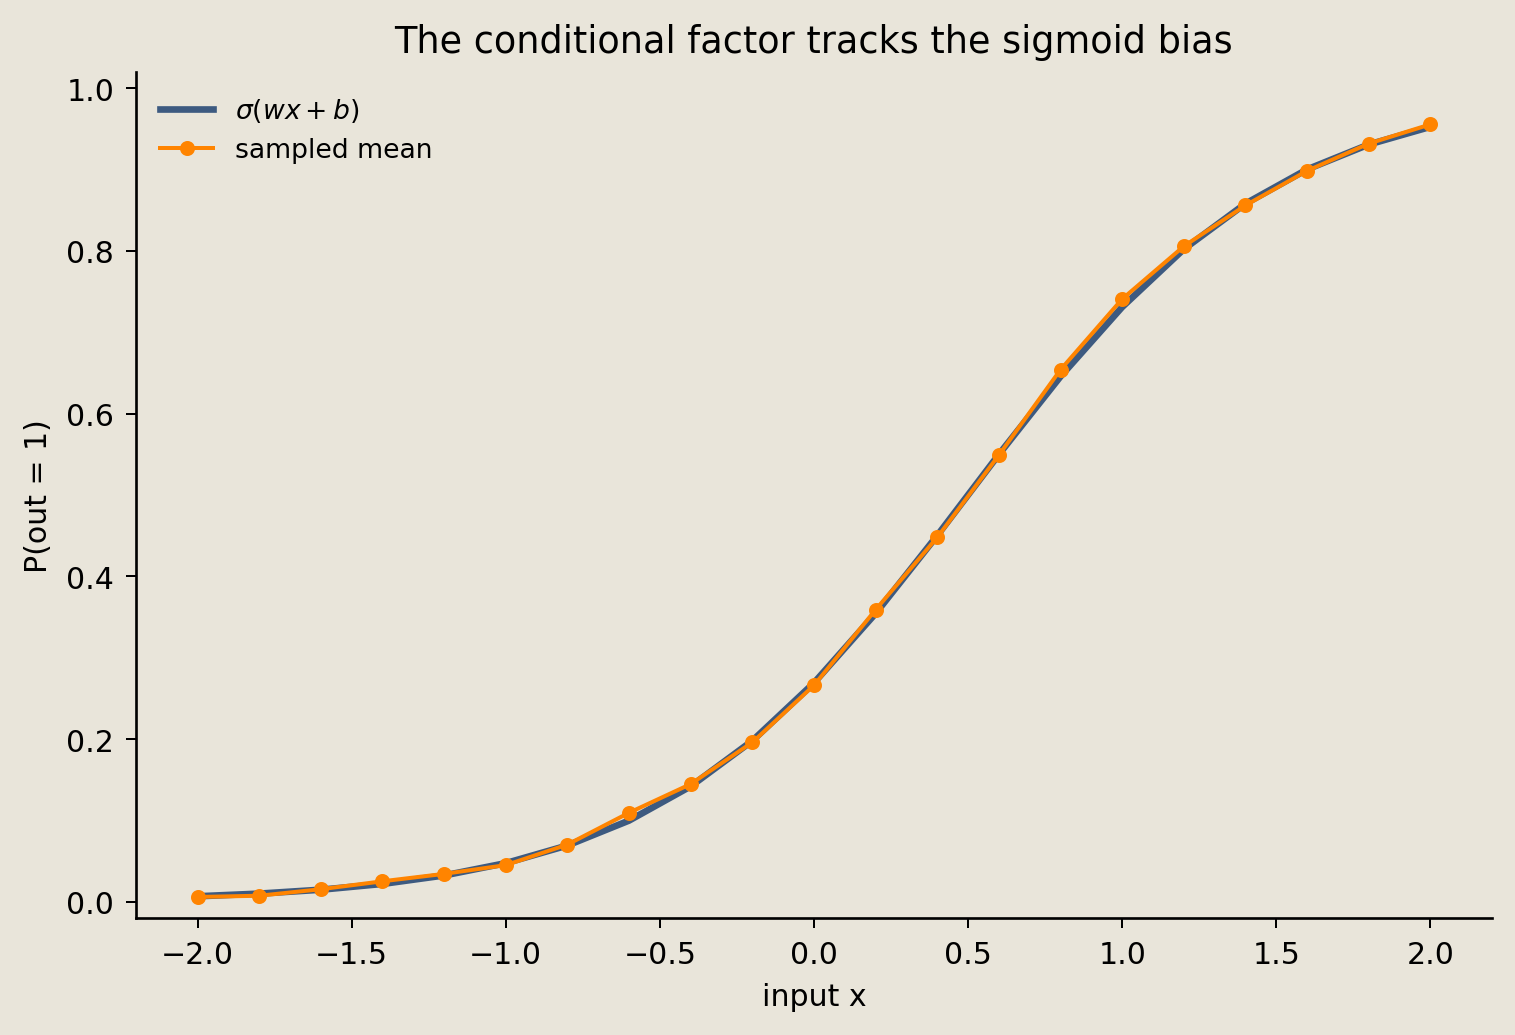

In [11]:
fig = P_samp.plot_conditional_sweep(np.asarray(xs), sampled, exact_curve)
savefig(fig, "15_conditional_sweep")

## Wiring tutorial factors into a Torx directed factor graph

Two factors become a graph only once something decides which output feeds which input, and that decision is exactly what a Torx `Site` records. A `Site` places a factor in a graph: it names the parents, routes parent outputs to input ports, and selects a parameter slice with `param_key`. Torx `DFG` then walks these sites in topological order, parents first, then children [(Pearl 1988)](#ref-pearl-1988), which is all the ordering a directed factor graph needs to be sampled in one pass.

Several actors are on stage from here on, so the tables and figures below use these labels:

| Label used below | Owner |
|---|---|
| Torx primitive | `AbstractReferenceFactor`, `AbstractMatrixFactor`, `JaxPRNGSampler`, `Site`, `DFG`, `TiledFactor`, `ChainFactor` |
| Tutorial factor | the four notebook-defined classes and their probability formulas |
| Notebook JAX | batching, compilation, estimates, and checks |
| Plot helper | presentation only |

Here the concrete Torx graph contains two notebook-defined factors. `coin` draws first, and `out` receives the coin bit through the notebook function `to_drive`, which casts the integer bit into the float that the `drive` port declares. The graph itself keeps the Torx `sample(key, inputs, params)` contract, so we call the two-node graph exactly the way we called the single factor.

Tracing one concrete path through the fixed tutorial parameters shows what each actor contributes:

| Step | Value | Owner |
|---|---:|---|
| `CoinFactor.sample` | `coin = 1` | tutorial factor called by Torx DFG |
| `to_drive` | `{"drive": 1.0}` | notebook routing function |
| `ConditionalBit` score | $2(1)-1=1$ | tutorial formula |
| child probability | $P(\mathrm{out}=1)=\sigma(1)=0.731$ | tutorial factor called by Torx DFG |

The anatomy below shows the shared factor contract that makes such wiring possible at all: inputs and external parameters enter, and one sample leaves.


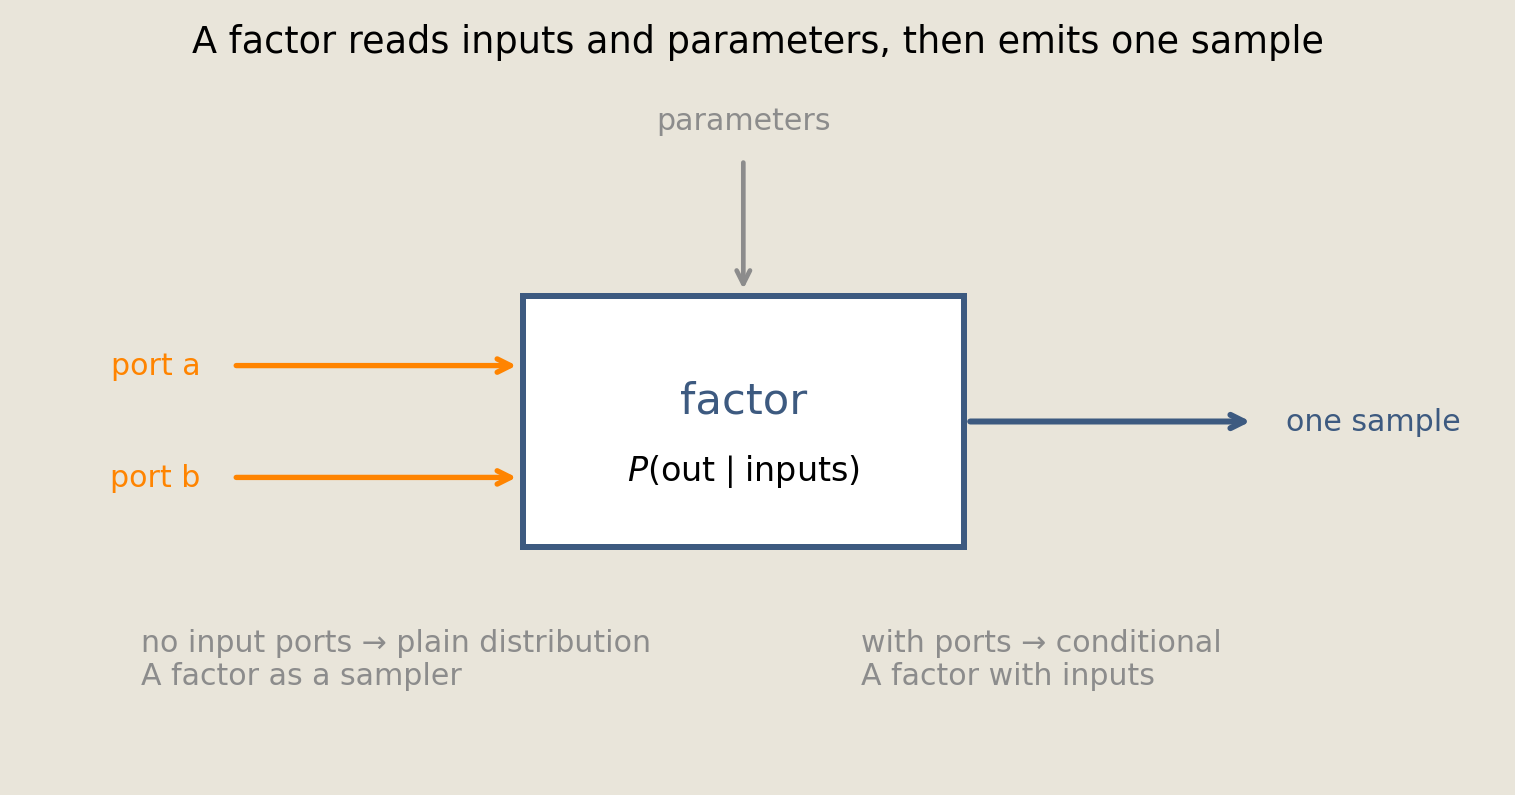

In [12]:
fig = P_sch.plot_factor_anatomy()
savefig(fig, "15_factor_anatomy")

In [13]:
def to_drive(outs):
    """Port the parent bit into the child's continuous drive input."""
    return {"drive": outs[0].astype(jnp.float32)}




In [14]:
sites = (
    # parentless coin: empty porting tuple, no parent outputs to route
    Site("coin", CoinFactor(), (), (), "src", info_key=None, site_info=None),
    Site(
        "out",
        ConditionalBit(),
        ("coin",),
        to_drive,
        "cond",
        info_key=None,
        site_info=None,
    ),
)
graph = DFG(sites, {}, "out")



In [15]:
# init_params walks the sites and returns one param slice per distinct param_key
dfg_params = graph.init_params(jax.random.key(SEED + 4))
one_draw = graph.sample(jax.random.key(SEED + 6), {}, dfg_params)
print(f"one DFG output draw: {int(one_draw)}")

keys = jax.random.split(jax.random.key(SEED + 7), 60_000)
@eqx.filter_jit
def sample_dfg_many(keys, params):
    """Draw one graph sample per key, batched under jit."""
    return jax.vmap(lambda k: graph.sample(k, {}, params))(keys)


dfg_out = sample_dfg_many(keys, dfg_params)
# Marginalize over the hidden coin by hand to check the graph sampler.
p_coin = float(jax.nn.sigmoid(dfg_params["src"]["bias"]))
w, b = dfg_params["cond"]["w"], dfg_params["cond"]["b"]
p_out_g0 = float(jax.nn.sigmoid(w * 0 + b))
p_out_g1 = float(jax.nn.sigmoid(w * 1 + b))
p_out_exact = (1 - p_coin) * p_out_g0 + p_coin * p_out_g1
p_out_emp = float(dfg_out.mean())
print(f"hand-computed P(out=1) = {p_out_exact:.3f}   sampled = {p_out_emp:.3f}")

one DFG output draw: 1


hand-computed P(out=1) = 0.546   sampled = 0.549


Across 60,000 graph draws the sampled mean of `out` is 0.549, while marginalizing the hidden coin by hand gives 0.546, so the Torx `DFG` reproduces the distribution that the two tutorial factors define jointly. That is the evidence that its routing and its parents-first ordering are both correct. The schematic below shows the two-node graph we just sampled.


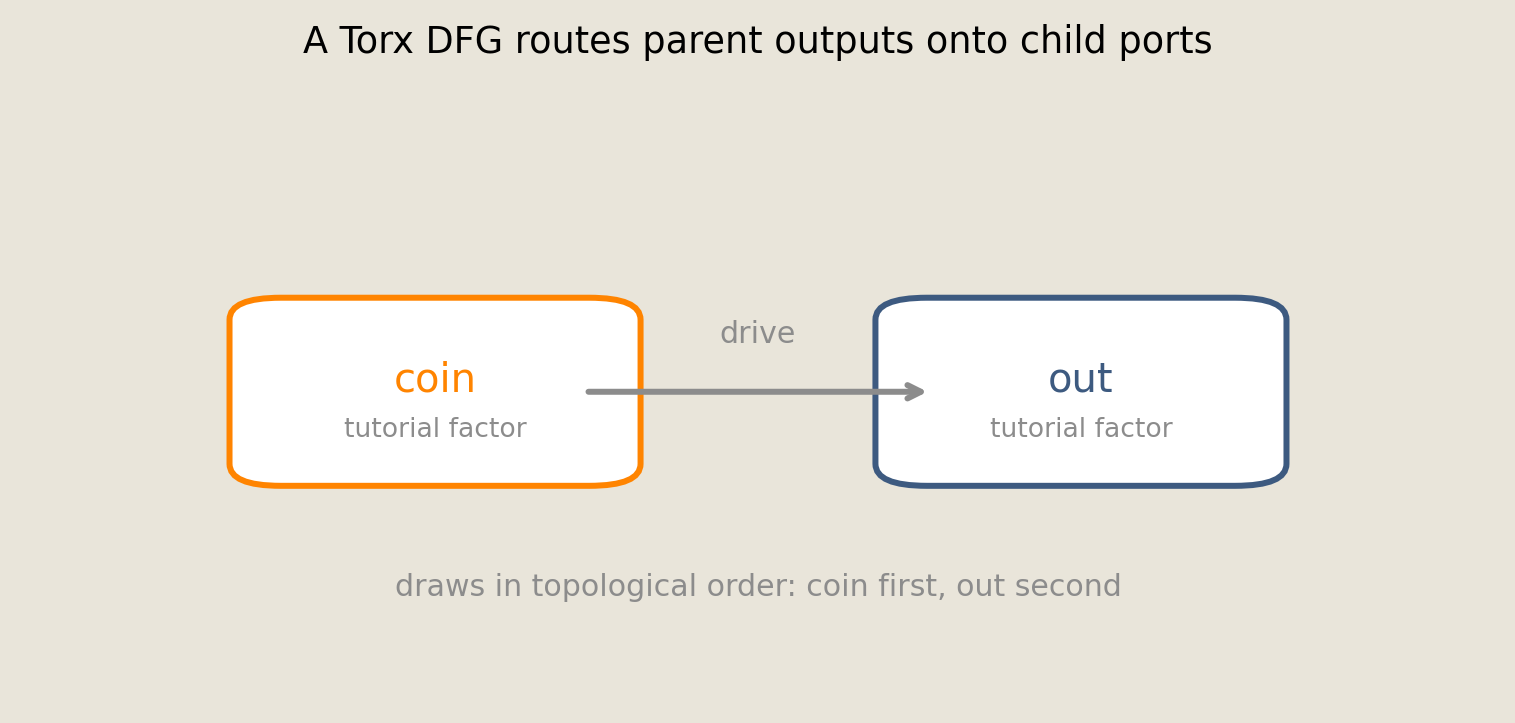

In [16]:
fig = P_sch.plot_two_node_dfg()
savefig(fig, "15_two_node_dfg")

## Exact probabilities as an opt-in capability

Sampling is the one thing every factor must do, but some factors can also report their distribution in closed form, and Torx lets them advertise that instead of demanding it of everyone. The notebook-defined `TinyCategorical` subclasses Torx `AbstractMatrixFactor`. It provides both the common sampling contract and the optional `get_log_probability_matrix` capability.

A matrix factor uses rows for input configurations and columns for output configurations, and `input_states` and `output_states` fix that ordering. This factor has no inputs, so its matrix has one row for the empty input configuration and three columns ordered as `x = 0, 1, 2`. Each matrix entry is a normalized log probability, which means exponentiating the row gives probabilities that sum to one.

One wrinkle when reading the draws: samples return a dictionary keyed by output name, so we read them with `["x"]`.


In [17]:
class TinyCategorical(AbstractMatrixFactor):
    """A finite 3-state pdit, no inputs, that also reports exact probabilities."""

    input_states: dict[str, jax.Array]
    output_states: dict[str, jax.Array]

    def __init__(self):
        self.input_states = {}
        self.output_states = {"x": jnp.arange(3)}

    def init_params(self, key):
        return {"logits": jnp.array([0.2, 1.0, -0.5])}

    def sample(self, key, inputs, params, info=None, site_info=None, return_aux=False):
        row = self.get_log_probability_matrix(params, info, site_info)[0]
        out = self.get_nth_output_state(jax.random.categorical(key, row))
        return (out, None) if return_aux else out

    def get_log_probability_matrix(self, params, info=None, site_info=None):
        logits = params["logits"]
        return (logits - jax.scipy.special.logsumexp(logits))[None, :]

In [18]:
cat = TinyCategorical()
cat_params = cat.init_params(jax.random.key(SEED + 8))
exact_p = np.asarray(jnp.exp(cat.get_log_probability_matrix(cat_params))[0])
print("exact probabilities:")
for s, p in enumerate(exact_p):
    print(f"  P(x = {s}) = {p:.3f}")
print(f"  sum        = {exact_p.sum():.3f}")

keys = jax.random.split(jax.random.key(SEED + 18), 50_000)
cat_draws = jax.vmap(lambda k: cat.sample(k, {}, cat_params))(keys)["x"]
# Compare the exact row with frequencies from many categorical draws.
emp_p = np.asarray(jax.vmap(lambda s: jnp.mean(cat_draws == s))(jnp.arange(3)))

exact probabilities:
  P(x = 0) = 0.269
  P(x = 1) = 0.598
  P(x = 2) = 0.133
  sum        = 1.000


The frequencies from 50,000 draws reproduce the exact row of 0.269, 0.598, and 0.133 to within the tolerance of 0.02 asserted at the end, so the opt-in probability table and the sampling contract describe one distribution rather than two that merely resemble each other. The bar chart below plots the two side by side, one pair of bars per state.

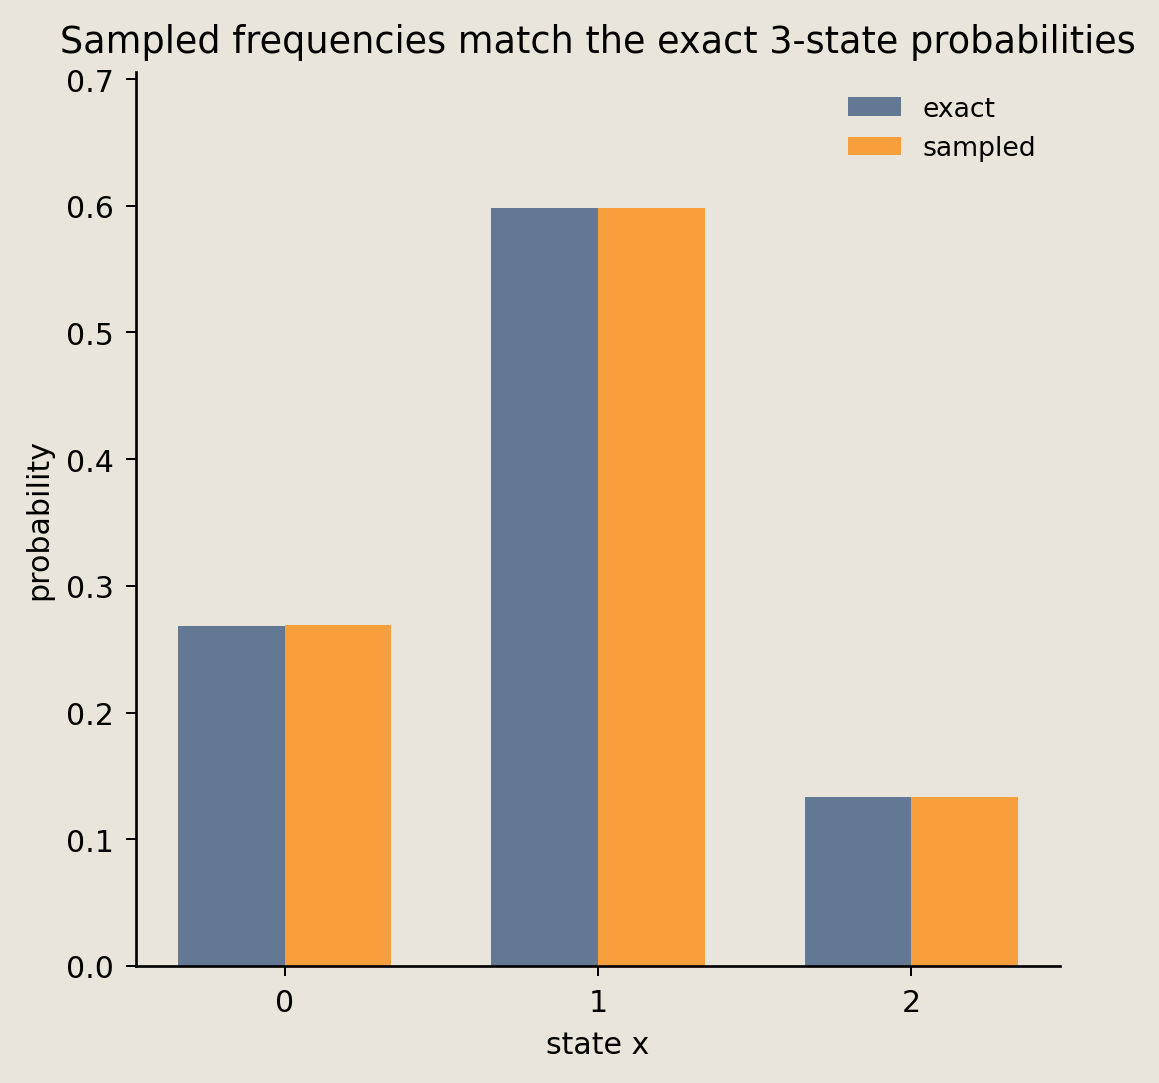

In [19]:
fig = P_samp.plot_categorical_parity(exact_p, emp_p)
savefig(fig, "15_categorical_parity")

## Torx composites around a tutorial transition

Two needs come up constantly in practice: running many copies of one factor at once, and running one factor repeatedly on its own output. Torx covers both with composites, and we build them around a transition of our own. The notebook-defined `FlipFactor` supplies the transition formula, Torx `TiledFactor` runs eight weight-tied copies in parallel, and Torx `ChainFactor` repeats five weight-tied steps while feeding each output back to the `state` port. Weight-tied means every copy or step reads one shared parameter slice instead of holding a slice of its own.


In [20]:
class FlipFactor(AbstractReferenceFactor):
    """P(next | state): a 2-state telegraph step. Input port and output are both pbits."""

    input_ports: dict[str, jax.ShapeDtypeStruct] = eqx.field(static=True)
    output_spec: jax.ShapeDtypeStruct = eqx.field(static=True)

    def __init__(self):
        self.input_ports = {"state": BIT}  # same dtype as the output: int to int
        self.output_spec = BIT

    def init_params(self, key):
        return {"w": jnp.array(1.5), "b": jnp.array(0.0)}

    def sample(self, key, inputs, params, info=None, site_info=None, return_aux=False):
        gamma = params["b"] + params["w"] * (2 * inputs["state"] - 1)
        out = jax.random.bernoulli(key, jax.nn.sigmoid(gamma)).astype(jnp.int32)
        return (out, None) if return_aux else out

In [21]:
flip = FlipFactor()
flip_params = flip.init_params(jax.random.key(SEED + 9))

# Torx TiledFactor: 8 tied copies of the notebook-defined transition.
tiled = TiledFactor(flip, n_tiles=8, weight_tied=True)
tiled_out = tiled.sample(
    jax.random.key(SEED + 10), {"state": jnp.zeros(8, jnp.int32)}, flip_params
)

# Torx ChainFactor: 5 tied steps with output fed back to state.
chain = ChainFactor(flip, n_steps=5, feedback_porting_fn="state", weight_tied=True)
chain_out = chain.sample(
    jax.random.key(SEED + 11), {"state": jnp.array(0, jnp.int32)}, flip_params
)
print(f"tiled 8 parallel draws: {np.asarray(tiled_out)}")
print(f"chain after 5 steps:    {int(chain_out)}")

tiled 8 parallel draws: [1 0 0 0 1 0 1 0]
chain after 5 steps:    1


Tying the weights is what these two composites are really demonstrating. Both reuse the single `FlipFactor` unchanged and hand it one parameter slice, so the tile's eight parallel draws share that same slice, and the chain threads the state through the same tied transition five times before returning the state after the fifth fed-back step. Neither composite alters the `sample` contract, so we call both of them exactly the way we call the single factor.

## One sampling interface at every level

Nothing about the calling convention changed as we moved up in scale, and that is the design point worth carrying away. All five objects keep the same basic shape: read inputs and parameters, then return a sample. A Torx `DFG` arranges `Site` factors in a DAG and samples them in topological order, whereas a PSC specializes `AbstractDFG` by fixing factors into circuit wiring instead. Composite factors sit at the same level as a plain factor, because they wrap or repeat another factor without changing its `sample` interface.

That shared interface is why the two entry points into Torx look different yet compose alike: [notebook 01](01_introduction_to_parametrised_stochastic_circuits.ipynb) uses the PSC side, while [notebook 16](16_gibbs_sampling_factor_graph.ipynb) uses factor composition.


## Verification

Finally, we turn each estimate above into a check that would fail if the composition were wrong. We assert the estimates computed above against their exact values, and we hold the composite factors to a stricter standard, because a composite that only reorganizes calls should not change a single draw. So we add deterministic same-key checks, meaning we feed the composite and a hand-written equivalent the identical random keys and require identical results: `TiledFactor` must equal a manual `vmap` over split keys, and `ChainFactor` must equal a manual loop that feeds each step's output back with the same split keys. We also compare a one-step chain against the bare factor.

In [22]:
COIN_MEAN_TOL = 0.02  # ~5 sigma at N=20000
COND_SWEEP_TOL = 0.03  # finite-sample
DFG_MEAN_TOL = 0.02  # finite-sample
CAT_FREQ_TOL = 0.02  # finite-sample
CHAIN_MEAN_TOL = 0.03  # finite-sample



In [23]:
assert abs(coin_mean - coin_target) < COIN_MEAN_TOL, (coin_mean, coin_target)
assert np.max(np.abs(sampled - exact_curve)) < COND_SWEEP_TOL
assert abs(p_out_emp - p_out_exact) < DFG_MEAN_TOL, (p_out_emp, p_out_exact)
assert abs(exact_p.sum() - 1.0) < 1e-5
assert np.max(np.abs(emp_p - exact_p)) < CAT_FREQ_TOL, (emp_p, exact_p)



In [24]:
# deterministic same-key check: TiledFactor == manual vmap over split keys
tiled_ref = jax.vmap(
    lambda k: flip.sample(k, {"state": jnp.array(0, jnp.int32)}, flip_params)
)(jax.random.split(jax.random.key(SEED + 10), 8))
np.testing.assert_array_equal(np.asarray(tiled_out), np.asarray(tiled_ref))



In [25]:
# deterministic same-key check: ChainFactor(n_steps=5) == manual feedback scan
manual_state = jnp.array(0, jnp.int32)
for step_key in jax.random.split(jax.random.key(SEED + 11), 5):
    manual_state = flip.sample(step_key, {"state": manual_state}, flip_params)
assert int(chain_out) == int(manual_state), (int(chain_out), int(manual_state))



In [26]:
chain1 = ChainFactor(flip, n_steps=1, feedback_porting_fn="state", weight_tied=True)
seed_state = jnp.array(0, jnp.int32)
chain_keys = jax.random.split(jax.random.key(SEED + 12), 20_000)
flip_keys = jax.random.split(jax.random.key(SEED + 13), 20_000)
chain1_draws = jax.vmap(lambda k: chain1.sample(k, {"state": seed_state}, flip_params))(
    chain_keys
)
flip_draws = jax.vmap(lambda k: flip.sample(k, {"state": seed_state}, flip_params))(
    flip_keys
)
assert abs(float(chain1_draws.mean() - flip_draws.mean())) < CHAIN_MEAN_TOL
# ChainFactor splits step keys internally.
chain_key = jax.random.key(SEED + 12)
one_step = chain1.sample(chain_key, {"state": seed_state}, flip_params)
single = flip.sample(
    jax.random.split(chain_key, 1)[0], {"state": seed_state}, flip_params
)
assert int(one_step) == int(single), (one_step, single)
print("all checks passed")

all checks passed


## Conclusion

We composed notebook-defined tutorial factors with Torx library primitives, and the division of labour is the thing to carry forward.

- The custom classes contain the tutorial probability formulas.
- Torx supplies the factor contracts, `JaxPRNGSampler`, `Site`, `DFG`, `TiledFactor`, and `ChainFactor`.
- A Torx DFG is a directed sampler DAG, distinct from the conventional bipartite definition of a factor graph.
- A PSC subclasses `AbstractDFG` as a circuit-shaped implementation and is not a subclass of concrete `DFG`.

For the circuit-shaped view, go back to [notebook 01](01_introduction_to_parametrised_stochastic_circuits.ipynb). For the larger Ising model, continue to [notebook 16](16_gibbs_sampling_factor_graph.ipynb).

## References

1. <span id="ref-kschischang-2001"></span>Kschischang, F.R., Frey, B.J., Loeliger, H.A. 2001. [*Factor graphs and the sum-product algorithm*](https://doi.org/10.1109/18.910572). IEEE Transactions on Information Theory 47(2), 498-519.
2. <span id="ref-pearl-1988"></span>Pearl, J. 1988. [*Probabilistic Reasoning in Intelligent Systems*](https://doi.org/10.1016/C2009-0-27609-4). Morgan Kaufmann. Directed acyclic graphical models and ancestral generation.
